**Overview**  
This notebook describes the process of regression model (XGBRegressor) optimization with hyperopt package and checking for $R^2$ and RMSE values

In [22]:
import numpy as np
import pandas as pd
from rdkit import RDConfig
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from rdkit import Chem
import datamol as dm
from rdkit.Chem import AllChem

from functools import partial
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
from hyperopt import tpe, Trials, hp, STATUS_OK, fmin

In [23]:
with open('viscosity.pickle', 'rb') as inp:
    target = pickle.load(inp)

In [24]:
with open('X_standard_dropped.pickle', 'rb') as inp:
    X = pickle.load(inp)

Viscosity values are given in cP, so now let's convert them into Pa*s and make a logarithm of them to reduce the range of values

In [25]:
target = target / 1000
target = np.log(target)

Here we just repeat the process of optimization with hyperopt package: get objective function and function for best model retrieval, and minimize the objective function with fmin function from hyperopt

In [32]:
def objective(params, estimator, X, target):
    pipe = make_pipeline(MinMaxScaler(), estimator)
    pipe.set_params(**params)
    score = cross_val_score(pipe, X, target, scoring = 'neg_root_mean_squared_error')
    return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe}
    

In [35]:
trials = Trials()

In [36]:
space = {'xgbregressor__n_estimators':hp.randint('n_estimators', 1, 30),
         'xgbregressor__learning_rate': hp.loguniform('learning_rate', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbregressor__reg_alpha':hp.loguniform(label = 'reg_alpha', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbregressor__max_depth':hp.randint('max_depth', 1, 100)}

In [37]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['Trained_model']

In [39]:
estimator = XGBRegressor(random_state = 0)
best = fmin(partial(objective, estimator = estimator, X = X, target = target), max_evals=50, algo = tpe.suggest, trials = trials, space=space)

 68%|██████▊   | 34/50 [03:34<01:00,  3.78s/trial, best loss: 3.630004148480605] 

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\model_selection\_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\

 70%|███████   | 35/50 [03:41<01:08,  4.59s/trial, best loss: 3.630004148480605]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\model_selection\_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\

100%|██████████| 50/50 [05:32<00:00,  6.64s/trial, best loss: 3.5900000094514573]


Here are the optimal parameters

In [40]:
print(best)

{'learning_rate': 0.08281620475860722, 'max_depth': 3, 'n_estimators': 28, 'reg_alpha': 0.28176039115730855}


And trained model

In [41]:
trained_model = get_best_model_from_trials(trials)

**Check for **$R^{2}$****

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, target, random_state = 1)
trained_model.fit(X_train, y_train)
r2 = r2_score(y_test, trained_model.predict(X_test))
rmse = root_mean_squared_error(y_test, trained_model.predict(X_test))
print('R2 value is {}'.format(r2))
print('RMSE value is {}'.format(rmse))


R2 value is 0.5149329887391734
RMSE value is 2.745951209455948


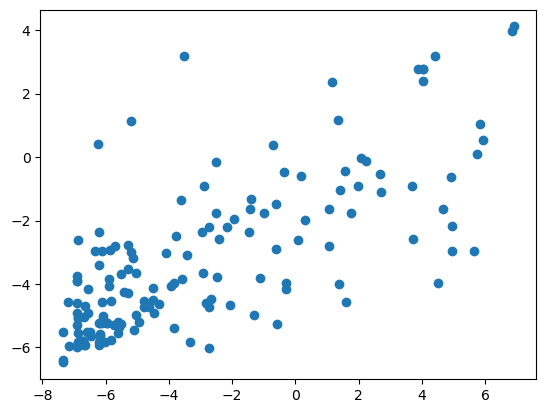

In [52]:
plt.plot(y_test, trained_model.predict(X_test), 'o')

**Create final calculator**

In [53]:
trained_model = trained_model.fit(X, target)